In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
events=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\events.csv")
order_items=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\order_items.csv")
orders=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\orders.csv")
products=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\products.csv")
reviews=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\reviews.csv")
users=pd.read_csv("D:\\projects\\E-commerce\\ecommerce_dataset\\users.csv")

In [3]:
events.head()

,event_id,user_id,product_id,event_type,event_timestamp
0,E00000001,U009798,P001393,cart,2025-07-08T14:28:55.893919
1,E00000002,U005881,P000669,view,2025-10-19T23:00:44.067982
2,E00000003,U006348,P001404,view,2025-05-09T07:02:42.256662
3,E00000004,U002664,P000400,cart,2025-07-19T22:47:07.019634
4,E00000005,U005776,P000392,view,2024-10-24T10:20:33.602165


In [4]:
 order_items.head()

,order_item_id,order_id,product_id,user_id,quantity,item_price,item_total
0,I00000001,O00000001,P001758,U009310,2,8.07,16.14
1,I00000002,O00000001,P001119,U009310,1,74.08,74.08
2,I00000003,O00000001,P001794,U009310,1,576.97,576.97
3,I00000004,O00000001,P001038,U009310,1,22.47,22.47
4,I00000005,O00000002,P000859,U003247,1,422.22,422.22


In [5]:
orders.head()

,order_id,user_id,order_date,order_status,total_amount
0,O00000001,U009310,2025-09-09T14:52:37.292731,processing,689.66
1,O00000002,U003247,2025-04-15T01:18:27.193404,completed,1666.85
2,O00000003,U007252,2025-04-27T15:37:48.008624,processing,665.06
3,O00000004,U008986,2025-10-04T20:35:22.204857,cancelled,689.50
4,O00000005,U008537,2024-11-13T08:15:18.498252,cancelled,860.50


In [6]:
products.head()

,product_id,product_name,category,brand,price,rating
0,P000001,Astra Be,Clothing,Astra,157.89,4.08
1,P000002,NeoTech Someone,Groceries,NeoTech,21.46,3.87
2,P000003,Acme Discuss,Sports,Acme,265.37,3.46
3,P000004,Nimbus South,Electronics,Nimbus,541.41,4.14
4,P000005,Astra Capital,Home & Kitchen,Astra,198.00,3.97


In [7]:
 reviews.head()

,review_id,order_id,product_id,user_id,rating,review_text,review_date
0,R00000528,O00000237,P001326,U001094,2,Color was different from images.,2025-10-14T12:03:56.749446
1,R00005792,O00002627,P000329,U001858,4,Highly recommend this brand.,2024-10-09T08:04:50.171793
2,R00036604,O00016798,P001160,U008109,4,Highly recommend this brand.,2024-06-03T05:11:16.787214
3,R00040163,O00018414,P001427,U006835,5,Highly recommend this brand.,2024-02-12T06:41:50.215810
4,R00031127,O00014300,P001639,U007148,3,Item arrived damaged.,2025-01-20T05:32:09.398860


In [8]:
 users.head()

,user_id,name,email,gender,city,signup_date
0,U000001,Angel Hill,donaldgarcia@example.net,Other,New Roberttown,2025-03-13
1,U000002,Jesse Guzman,jennifermiles@example.com,Male,South Bridget,2024-03-05
2,U000003,Adam Shaffer,jpeterson@example.org,Male,Curtisfurt,2025-07-07
3,U000004,Melanie Munoz,blairamanda@example.com,Other,New Kellystad,2024-03-07
4,U000005,Janet Williams,kendragalloway@example.org,Female,South Joshuastad,2025-01-29



##  Quick Overview of Tables

We first inspect shapes (rows, columns) and column names.


In [9]:

tables = {
    "events": events,
    "order_items": order_items,
    "orders": orders,
    "products": products,
    "reviews": reviews,
    "users": users,
}

for name, df in tables.items():
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))



=== EVENTS ===
Shape: (80000, 5)
Columns: ['event_id', 'user_id', 'product_id', 'event_type', 'event_timestamp']

=== ORDER_ITEMS ===
Shape: (43525, 7)
Columns: ['order_item_id', 'order_id', 'product_id', 'user_id', 'quantity', 'item_price', 'item_total']

=== ORDERS ===
Shape: (20000, 5)
Columns: ['order_id', 'user_id', 'order_date', 'order_status', 'total_amount']

=== PRODUCTS ===
Shape: (2000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'price', 'rating']

=== REVIEWS ===
Shape: (15000, 7)
Columns: ['review_id', 'order_id', 'product_id', 'user_id', 'rating', 'review_text', 'review_date']

=== USERS ===
Shape: (10000, 6)
Columns: ['user_id', 'name', 'email', 'gender', 'city', 'signup_date']



##  Data Types & Missing Values

Check data types and missing values to plan cleaning steps.


In [10]:

for name, df in tables.items():
    print(f"\n=== {name.upper()} dtypes ===")
    print(df.dtypes)



=== EVENTS dtypes ===
event_id           object
user_id            object
product_id         object
event_type         object
event_timestamp    object
dtype: object

=== ORDER_ITEMS dtypes ===
order_item_id     object
order_id          object
product_id        object
user_id           object
quantity           int64
item_price       float64
item_total       float64
dtype: object

=== ORDERS dtypes ===
order_id         object
user_id          object
order_date       object
order_status     object
total_amount    float64
dtype: object

=== PRODUCTS dtypes ===
product_id       object
product_name     object
category         object
brand            object
price           float64
rating          float64
dtype: object

=== REVIEWS dtypes ===
review_id      object
order_id       object
product_id     object
user_id        object
rating          int64
review_text    object
review_date    object
dtype: object

=== USERS dtypes ===
user_id        object
name           object
email          obj

In [11]:

for name, df in tables.items():
    print(f"\n=== {name.upper()} missing values ===")
    print(df.isna().sum())



=== EVENTS missing values ===
event_id           0
user_id            0
product_id         0
event_type         0
event_timestamp    0
dtype: int64

=== ORDER_ITEMS missing values ===
order_item_id    0
order_id         0
product_id       0
user_id          0
quantity         0
item_price       0
item_total       0
dtype: int64

=== ORDERS missing values ===
order_id        0
user_id         0
order_date      0
order_status    0
total_amount    0
dtype: int64

=== PRODUCTS missing values ===
product_id      0
product_name    0
category        0
brand           0
price           0
rating          0
dtype: int64

=== REVIEWS missing values ===
review_id      0
order_id       0
product_id     0
user_id        0
rating         0
review_text    0
review_date    0
dtype: int64

=== USERS missing values ===
user_id        0
name           0
email          0
gender         0
city           0
signup_date    0
dtype: int64



##  Basic Cleaning & Type Conversions

- Ensure ID columns are strings
- Convert date/time columns to `datetime`


In [12]:

# Ensure ID columns are strings and strip spaces
id_columns_by_table = {
    "events": ["event_id", "user_id", "product_id"],
    "order_items": ["order_item_id", "order_id", "product_id", "user_id"],
    "orders": ["order_id", "user_id"],
    "products": ["product_id"],
    "reviews": ["review_id", "user_id", "product_id"],
    "users": ["user_id"],
}

for name, cols in id_columns_by_table.items():
    df = tables[name]
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# Convert date / datetime columns
date_cols = {
    "events": ["event_timestamp"],
    "orders": ["order_date"],
    "reviews": ["review_timestamp"],
    "users": ["signup_date"],
}

for name, cols in date_cols.items():
    df = tables[name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])

# Reassign cleaned dataframes
events = tables["events"]
order_items = tables["order_items"]
orders = tables["orders"]
products = tables["products"]
reviews = tables["reviews"]
users = tables["users"]



##  Users Analysis (EDA)

We analyze user signups, demographics, and geography.


In [13]:

users.head()

,user_id,name,email,gender,city,signup_date
0,U000001,Angel Hill,donaldgarcia@example.net,Other,New Roberttown,2025-03-13
1,U000002,Jesse Guzman,jennifermiles@example.com,Male,South Bridget,2024-03-05
2,U000003,Adam Shaffer,jpeterson@example.org,Male,Curtisfurt,2025-07-07
3,U000004,Melanie Munoz,blairamanda@example.com,Other,New Kellystad,2024-03-07
4,U000005,Janet Williams,kendragalloway@example.org,Female,South Joshuastad,2025-01-29


In [14]:

print("Total users:", len(users))
print("\nGender distribution:")
print(users["gender"].value_counts())

print("\nTop 10 cities by user count:")
print(users["city"].value_counts().head(10))


Total users: 10000

Gender distribution:
gender
Other     3419
Female    3334
Male      3247
Name: count, dtype: int64

Top 10 cities by user count:
city
North Michael    13
West Michelle    11
Michaelmouth     10
New Michael       9
Port Kimberly     9
East David        9
West Michael      9
East Michael      9
Lake John         9
West Jennifer     9
Name: count, dtype: int64


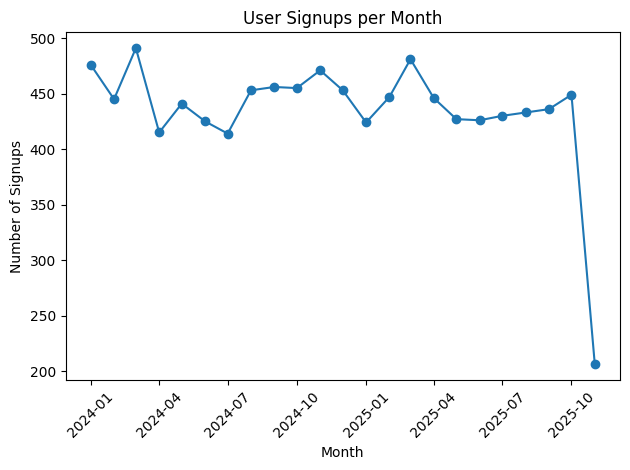

In [15]:

# Monthly signup trend
signup_monthly = users["signup_date"].dt.to_period("M").value_counts().sort_index()

signup_monthly_index = signup_monthly.index.to_timestamp()

plt.figure()
plt.plot(signup_monthly_index, signup_monthly.values, marker="o")
plt.title("User Signups per Month")
plt.xlabel("Month")
plt.ylabel("Number of Signups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##  Events Analysis (Views, Carts, Purchases)

We inspect user interactions with products.


In [16]:
events.head()

,event_id,user_id,product_id,event_type,event_timestamp
0,E00000001,U009798,P001393,cart,2025-07-08 14:28:55.893919
1,E00000002,U005881,P000669,view,2025-10-19 23:00:44.067982
2,E00000003,U006348,P001404,view,2025-05-09 07:02:42.256662
3,E00000004,U002664,P000400,cart,2025-07-19 22:47:07.019634
4,E00000005,U005776,P000392,view,2024-10-24 10:20:33.602165


In [17]:

print("Total events:", len(events))
print("Unique users in events:", events["user_id"].nunique())
print("Unique products in events:", events["product_id"].nunique())

print("\nEvent type distribution:")
print(events["event_type"].value_counts())


Total events: 80000
Unique users in events: 9995
Unique products in events: 2000

Event type distribution:
event_type
view        56013
cart        12035
wishlist     7946
purchase     4006
Name: count, dtype: int64


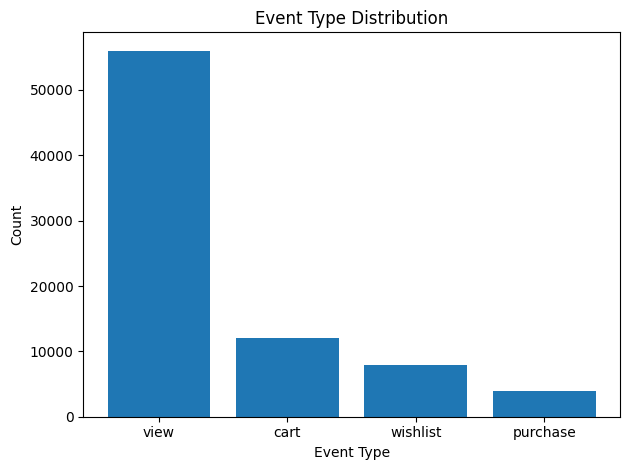

In [18]:

event_counts = events["event_type"].value_counts()

plt.figure()
plt.bar(event_counts.index.astype(str), event_counts.values)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



##  Orders Analysis

We analyze order volume and customer activity.


In [19]:
orders.head()

,order_id,user_id,order_date,order_status,total_amount
0,O00000001,U009310,2025-09-09 14:52:37.292731,processing,689.66
1,O00000002,U003247,2025-04-15 01:18:27.193404,completed,1666.85
2,O00000003,U007252,2025-04-27 15:37:48.008624,processing,665.06
3,O00000004,U008986,2025-10-04 20:35:22.204857,cancelled,689.50
4,O00000005,U008537,2024-11-13 08:15:18.498252,cancelled,860.50


In [20]:

print("Total orders:", len(orders))
print("Unique customers with orders:", orders["user_id"].nunique())

if "order_status" in orders.columns:
    print("\nOrder status distribution:")
    print(orders["order_status"].value_counts())

if "payment_method" in orders.columns:
    print("\nPayment method distribution:")
    print(orders["payment_method"].value_counts())


Total orders: 20000
Unique customers with orders: 8635

Order status distribution:
order_status
shipped       4113
returned      4066
completed     4021
cancelled     3920
processing    3880
Name: count, dtype: int64


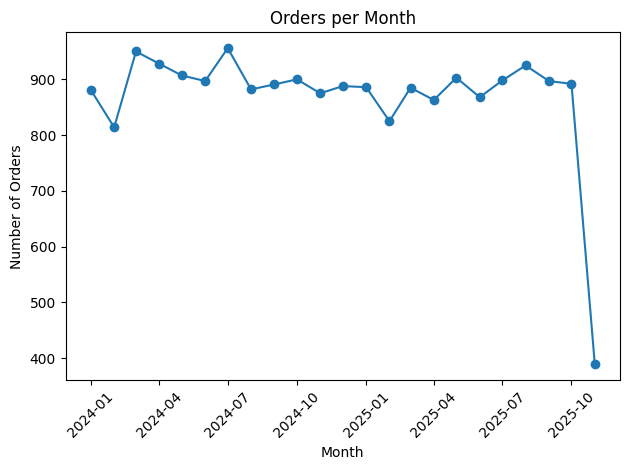

In [21]:

# Monthly orders
orders_monthly = orders["order_date"].dt.to_period("M").value_counts().sort_index()
orders_monthly_index = orders_monthly.index.to_timestamp()

plt.figure()
plt.plot(orders_monthly_index, orders_monthly.values, marker="o")
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



##  Order Items & Revenue Analysis

We analyze line items to understand quantities, pricing, and revenue.


In [22]:
order_items.head()

,order_item_id,order_id,product_id,user_id,quantity,item_price,item_total
0,I00000001,O00000001,P001758,U009310,2,8.07,16.14
1,I00000002,O00000001,P001119,U009310,1,74.08,74.08
2,I00000003,O00000001,P001794,U009310,1,576.97,576.97
3,I00000004,O00000001,P001038,U009310,1,22.47,22.47
4,I00000005,O00000002,P000859,U003247,1,422.22,422.22


In [23]:

print("Order items shape:", order_items.shape)
print("\nQuantity stats:")
print(order_items["quantity"].describe())

print("\nItem price stats:")
print(order_items["item_price"].describe())

print("\nItem total stats:")
print(order_items["item_total"].describe())


Order items shape: (43525, 7)

Quantity stats:
count    43525.000000
mean         1.397312
std          0.660717
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: quantity, dtype: float64

Item price stats:
count    43525.000000
mean       196.636976
std        297.259224
min          1.110000
25%         36.400000
50%         83.170000
75%        208.050000
max       2338.130000
Name: item_price, dtype: float64

Item total stats:
count    43525.000000
mean       273.835013
std        471.585104
min          1.110000
25%         44.590000
50%        105.340000
75%        274.980000
max       7014.390000
Name: item_total, dtype: float64


In [24]:

# Basic revenue metrics
total_revenue = order_items["item_total"].sum()
avg_order_value = orders["order_total"].mean() if "order_total" in orders.columns else total_revenue / len(orders)

print("Total revenue:", round(total_revenue, 2))
print("Average order value (AOV):", round(avg_order_value, 2))


Total revenue: 11918668.95
Average order value (AOV): 595.93


In [25]:

# Revenue by product
product_revenue = (
    order_items.groupby("product_id")["item_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue


product_id
P001527    73275.12
P001024    65467.64
P000021    62032.60
P000910    60784.10
P000136    56419.48
P001925    56311.92
P000461    54411.20
P001049    54399.32
P000198    54105.20
P000555    53489.18
Name: item_total, dtype: float64

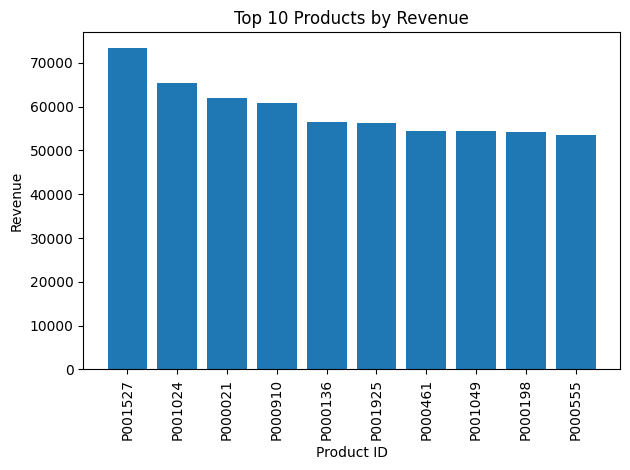

In [26]:

plt.figure()
plt.bar(product_revenue.index.astype(str), product_revenue.values)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



## Products Analysis

We examine the product catalog and pricing.


In [27]:
products.head()

,product_id,product_name,category,brand,price,rating
0,P000001,Astra Be,Clothing,Astra,157.89,4.08
1,P000002,NeoTech Someone,Groceries,NeoTech,21.46,3.87
2,P000003,Acme Discuss,Sports,Acme,265.37,3.46
3,P000004,Nimbus South,Electronics,Nimbus,541.41,4.14
4,P000005,Astra Capital,Home & Kitchen,Astra,198.00,3.97


In [28]:

print("Total products:", len(products))

if "category" in products.columns:
    print("\nTop categories:")
    print(products["category"].value_counts().head(10))

if "price" in products.columns:
    print("\nPrice stats:")
    print(products["price"].describe())


Total products: 2000

Top categories:
category
Clothing          213
Toys              213
Pet Supplies      212
Beauty            207
Electronics       203
Home & Kitchen    199
Books             194
Automotive        193
Groceries         183
Sports            183
Name: count, dtype: int64

Price stats:
count    2000.000000
mean      200.342230
std       302.742395
min         1.110000
25%        36.335000
50%        84.220000
75%       210.817500
max      2338.130000
Name: price, dtype: float64



##  Reviews & Ratings Analysis

We analyze rating distribution and review activity.


In [29]:
reviews.head()

,review_id,order_id,product_id,user_id,rating,review_text,review_date
0,R00000528,O00000237,P001326,U001094,2,Color was different from images.,2025-10-14T12:03:56.749446
1,R00005792,O00002627,P000329,U001858,4,Highly recommend this brand.,2024-10-09T08:04:50.171793
2,R00036604,O00016798,P001160,U008109,4,Highly recommend this brand.,2024-06-03T05:11:16.787214
3,R00040163,O00018414,P001427,U006835,5,Highly recommend this brand.,2024-02-12T06:41:50.215810
4,R00031127,O00014300,P001639,U007148,3,Item arrived damaged.,2025-01-20T05:32:09.398860


In [30]:

print("Total reviews:", len(reviews))
print("Unique users with reviews:", reviews["user_id"].nunique())
print("Unique products with reviews:", reviews["product_id"].nunique())

if "rating" in reviews.columns:
    print("\nRating distribution:")
    print(reviews["rating"].value_counts().sort_index())


Total reviews: 15000
Unique users with reviews: 6660
Unique products with reviews: 1999

Rating distribution:
rating
1     594
2    2084
3    4289
4    4624
5    3409
Name: count, dtype: int64


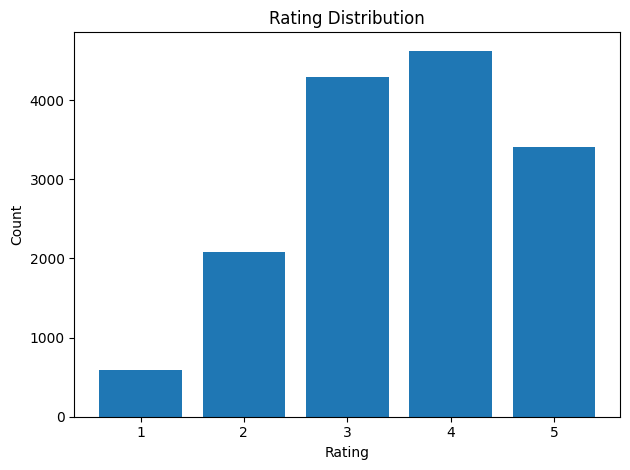

In [31]:

if "rating" in reviews.columns:
    rating_counts = reviews["rating"].value_counts().sort_index()
    plt.figure()
    plt.bar(rating_counts.index.astype(str), rating_counts.values)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



##  Joining Tables for Business Insights

We build joined datasets for deeper analysis, such as:

- **Order-level view with product details**
- **Customer-level metrics**


In [32]:

# Join order_items with products
order_items_products = order_items.merge(products, on="product_id", how="left")

# Join with orders
order_items_full = order_items_products.merge(orders, on=["order_id", "user_id"], how="left")

order_items_full.head()


,order_item_id,order_id,product_id,user_id,quantity,item_price,item_total,product_name,category,brand,price,rating,order_date,order_status,total_amount
0,I00000001,O00000001,P001758,U009310,2,8.07,16.14,Everest Whole,Pet Supplies,Everest,8.07,2.69,2025-09-09 14:52:37.292731,processing,689.66
1,I00000002,O00000001,P001119,U009310,1,74.08,74.08,Nimbus Minute,Beauty,Nimbus,74.08,3.62,2025-09-09 14:52:37.292731,processing,689.66
2,I00000003,O00000001,P001794,U009310,1,576.97,576.97,Willow Treatment,Automotive,Willow,576.97,3.89,2025-09-09 14:52:37.292731,processing,689.66
3,I00000004,O00000001,P001038,U009310,1,22.47,22.47,Nimbus Deal,Books,Nimbus,22.47,4.85,2025-09-09 14:52:37.292731,processing,689.66
4,I00000005,O00000002,P000859,U003247,1,422.22,422.22,Pulse Decide,Electronics,Pulse,422.22,3.51,2025-04-15 01:18:27.193404,completed,1666.85



###  Customer Metrics (Frequency, Revenue)

We compute key metrics per customer.


In [33]:

# Revenue per user
user_revenue = order_items_full.groupby("user_id")["item_total"].sum()

# Orders per user
user_orders = orders.groupby("user_id")["order_id"].nunique()

customer_metrics = pd.DataFrame({
    "total_revenue": user_revenue,
    "num_orders": user_orders,
}).fillna(0)

customer_metrics["avg_order_value"] = customer_metrics["total_revenue"] / customer_metrics["num_orders"].replace(0, np.nan)

customer_metrics.sort_values("total_revenue", ascending=False).head(10)


,total_revenue,num_orders,avg_order_value
user_id,,,
U009931,13288.88,4,3322.220000
U006233,11234.22,3,3744.740000
U006469,10953.18,4,2738.295000
U008370,10190.11,2,5095.055000
U005702,10175.81,6,1695.968333
U009903,10118.31,5,2023.662000
U000006,9952.28,6,1658.713333
U004906,9538.69,5,1907.738000
U006231,9486.29,2,4743.145000


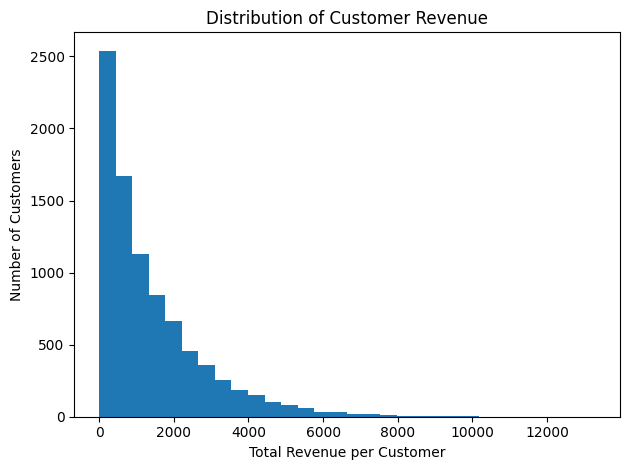

In [34]:

plt.figure()
plt.hist(customer_metrics["total_revenue"], bins=30)
plt.title("Distribution of Customer Revenue")
plt.xlabel("Total Revenue per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()



## Simple Conversion Funnel (Views → Carts → Purchases)

We approximate a simple funnel based on `events` and `orders`.


In [35]:

# Users who viewed at least one product
view_users = set(events.loc[events["event_type"] == "view", "user_id"])

# Users who added at least one product to cart (if event_type 'cart' exists)
cart_users = set(events.loc[events["event_type"] == "cart", "user_id"]) if "cart" in events["event_type"].unique() else set()

# Users who completed at least one order
purchase_users = set(orders["user_id"].unique())

n_view = len(view_users)
n_cart = len(cart_users)
n_purchase = len(purchase_users)

print("Users with at least one view:", n_view)
print("Users with at least one cart event:", n_cart)
print("Users with at least one purchase:", n_purchase)

if n_view > 0:
    print("\nView → Cart conversion:", round(n_cart / n_view * 100, 2), "%")
    print("View → Purchase conversion:", round(n_purchase / n_view * 100, 2), "%")


Users with at least one view: 9961
Users with at least one cart event: 6994
Users with at least one purchase: 8635

View → Cart conversion: 70.21 %
View → Purchase conversion: 86.69 %


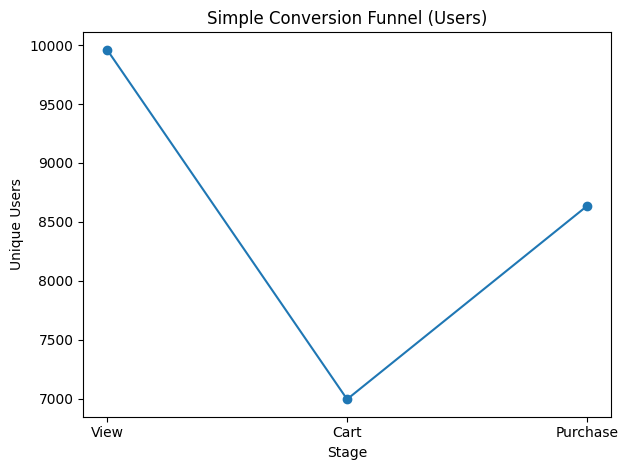

In [36]:

stages = ["View", "Cart", "Purchase"]
values = [n_view, n_cart, n_purchase]

plt.figure()
plt.plot(stages, values, marker="o")
plt.title("Simple Conversion Funnel (Users)")
plt.xlabel("Stage")
plt.ylabel("Unique Users")
plt.tight_layout()
plt.show()
